# ECG Preprocessing Pipeline for Dilated-SE-FireNet

Notebook này thực hiện tiền xử lý dữ liệu từ cơ sở dữ liệu **MIT-BIH Atrial Fibrillation Database (AFDB)** thô để tạo ra các tập dữ liệu huấn luyện, kiểm thử và đánh giá dưới dạng các tệp `.npy` phục vụ cho mô hình **Dilated-SE-FireNet**.

### 1. Cấu hình và Import thư viện

In [11]:
import os
import random
from pathlib import Path
import numpy as np
import scipy
from scipy.signal import butter, sosfilt, resample_poly
import wfdb
from wfdb import processing
import matplotlib.pyplot as plt

# Cấu hình chung cho ECG
TARGET_FS = 250
WINDOW_SECONDS = 10
WINDOW_SIZE = TARGET_FS * WINDOW_SECONDS  # 2500 mẫu
STEP_SIZE = int(WINDOW_SIZE * 0.2)        # 500 mẫu, overlap 80%
INPUT_SHAPE = (WINDOW_SIZE, 1)

# Thông số bộ lọc dải thông
LOW_CUT = 0.5
HIGH_CUT = 40.0
FILTER_ORDER = 4

# Cấu hình nhãn
LABEL_NORMAL = 0
LABEL_AFIB = 1
NUM_CLASSES = 2

LABEL_MAP = {
    "(N": LABEL_NORMAL,
    "(AFIB": LABEL_AFIB,
}

# Các thư mục dự án
PROJECT_ROOT = Path("..").resolve()
RAW_AFDB_DIR = PROJECT_ROOT / "database" / "physionet.org" / "files" / "afdb" / "1.0.0"
DATA_DIR = PROJECT_ROOT / "database" / "processed"

# Chia tập bệnh nhân (Patient-wise Split)
TRAIN_RECORDS = [
    "04043", "04936", "07162", "07859", "07879", "08455", "06426", "05121",
    "06995", "05261", "06453", "04015", "04908", "04048", "08434", "08378",
]
VAL_RECORDS = ["04746", "07910", "08219"]
EXCLUDED_RECORDS = {"00735", "03665"}

print(f"Thư mục raw data: {RAW_AFDB_DIR}")
print(f"Thư mục lưu dữ liệu: {DATA_DIR}")

Thư mục raw data: /home/pd/data/info_model/build_model/database/physionet.org/files/afdb/1.0.0
Thư mục lưu dữ liệu: /home/pd/data/info_model/build_model/database/processed


### 2. Định nghĩa hàm đọc dữ liệu thô và gán nhãn liên tục

In [ ]:
def read_raw_record(rec_name, raw_dir=RAW_AFDB_DIR):
    """
    Đọc tín hiệu kênh đầu tiên (channel 0) và annotation của record
    """
    rec_path = raw_dir / rec_name
    record = wfdb.rdrecord(str(rec_path), channels=[0])
    annotation = wfdb.rdann(str(rec_path), "atr")
    return record.p_signal[:, 0], annotation, int(record.fs)

def create_continuous_label_mask(annotation, signal_length, original_fs):
    """
    Tạo mảng nhãn liên tục (sample-by-sample) dựa trên các annotation đổi nhịp
    """
    mask = np.full(signal_length, -1, dtype=np.int8)
    ratio = TARGET_FS / float(original_fs)

    # 1. Trích xuất chỉ các rhythm annotations bắt đầu bằng dấu ngoặc '('
    rhythm_samples = []
    rhythm_notes = []
    for i, raw_note in enumerate(annotation.aux_note):
        note = raw_note.strip("\x00").strip()
        if note.startswith("("):
            rhythm_samples.append(annotation.sample[i])
            rhythm_notes.append(note)
            
    if not rhythm_samples:
        return mask

    # 2. Điền nhãn cho các khoảng nhịp tương ứng
    for i in range(len(rhythm_samples)):
        start = rhythm_samples[i]
        end = rhythm_samples[i + 1] if i < len(rhythm_samples) - 1 else int(signal_length / ratio)

        if int(original_fs) != TARGET_FS:
            start = int(start * ratio)
            end = int(end * ratio)

        start = max(0, min(start, signal_length))
        end = max(0, min(end, signal_length))

        note = rhythm_notes[i]
        if note in LABEL_MAP:
            mask[start:end] = LABEL_MAP[note]
        else:
            mask[start:end] = -1

    return mask

### 3. Bộ lọc nhiễu thông dải (Bandpass Filter)

In [5]:
def preprocess_signal(signal_data):
    """
    Lọc tín hiệu thông dải từ 0.5Hz đến 40Hz sử dụng bộ lọc Butterworth dạng sos
    """
    sig = signal_data.astype("float32")
    sig = sig - np.mean(sig)  # Loại bỏ DC offset ban đầu

    nyquist = 0.5 * TARGET_FS
    low = LOW_CUT / nyquist
    high = HIGH_CUT / nyquist
    sos = butter(FILTER_ORDER, [low, high], btype="band", output="sos")
    sig = sosfilt(sos, sig).astype("float32")
    return sig

### 4. Thuật toán kiểm tra chất lượng tín hiệu (Quality Validation)

In [ ]:
def has_flatline(segment, duration_threshold=0.2, std_threshold=0.005):
    """
    Kiểm tra xem cửa sổ có chứa đoạn đường thẳng (mất tín hiệu) không
    """
    chunk_len = int(duration_threshold * TARGET_FS)
    if chunk_len <= 0 or chunk_len >= len(segment):
        return False

    n = len(segment) // chunk_len
    for i in range(n):
        chunk = segment[i * chunk_len : (i + 1) * chunk_len]
        if np.std(chunk) < std_threshold:   # hàm kiểm tra standard deviation độ lệch chuẩn.
            return True
    return False

def validate_sinus_rhythm(qrs_in_window):
    """
    Kiểm tra chất lượng nhịp xoang (yêu cầu nhịp đều đặn và nhịp tim hợp lý)
    """
    if len(qrs_in_window) < 5:
        return False

    rr = np.diff(qrs_in_window)
    mean_rr = np.mean(rr)
    std_rr = np.std(rr)

    if mean_rr <= 0:
        return False

    cv = std_rr / mean_rr
    if cv > 0.15:
        return False

    # Cho phép tối đa 15% số khoảng RR lệch ngoài khoảng 20% so với trung bình để tránh nhiễu cục bộ
    lower = 0.8 * mean_rr
    upper = 1.2 * mean_rr
    in_range = (rr >= lower) & (rr <= upper)
    if np.mean(in_range) < 0.85:
        return False

    return True

def validate_afib_quality(qrs_in_window):
    """
    Kiểm tra tính hợp lệ của đoạn rung nhĩ (chỉ cần có tối thiểu số beat hợp lý)
    """
    return len(qrs_in_window) >= 5

### 5. Tiền xử lý cho một bản ghi đơn lẻ

In [7]:
def process_single_record(rec_name, raw_dir=RAW_AFDB_DIR):
    """
    Thực hiện toàn bộ pipeline tiền xử lý cho một bản ghi bệnh nhân
    """
    # 1. Đọc dữ liệu
    raw_sig, annotation, fs = read_raw_record(rec_name, raw_dir)

    # 2. Lọc nhiễu
    clean_sig = preprocess_signal(raw_sig)

    # 3. Tạo mask nhãn
    mask = create_continuous_label_mask(annotation, len(clean_sig), fs)

    # 4. Phát hiện QRS toàn cục (chạy 1 lần trên toàn bộ bản ghi dài)
    try:
        qrs_all = np.array(processing.xqrs_detect(sig=clean_sig, fs=TARGET_FS, verbose=False))
    except Exception as e:
        print(f"Warning: QRS detection failed for record {rec_name}: {e}")
        qrs_all = np.array([])

    X_rec, y_rec = [], []
    
    # Bỏ qua 2 giây đầu tiên của tín hiệu đã lọc để tránh biên nhiễu bộ lọc
    start_offset = 2 * TARGET_FS
    end_limit = len(clean_sig) - WINDOW_SIZE

    stats = {
        "total_windows": 0,
        "skipped_flatline": 0,
        "skipped_label": 0,
        "skipped_irregular_normal": 0,
        "skipped_garbage_afib": 0,
        "accepted_normal": 0,
        "accepted_afib": 0,
    }

    # Tạo các cửa sổ trượt
    for start_idx in range(start_offset, end_limit, STEP_SIZE):
        end_idx = start_idx + WINDOW_SIZE
        seg = clean_sig[start_idx:end_idx]
        m = mask[start_idx:end_idx]
        stats["total_windows"] += 1

        # Kiểm tra flatline
        if has_flatline(seg):
            stats["skipped_flatline"] += 1
            continue

        # Quyết định nhãn cho cửa sổ
        valid_ratio = np.mean(m != -1)
        if valid_ratio < 0.8:
            stats["skipped_label"] += 1
            continue

        afib_ratio = np.mean(m == LABEL_AFIB)
        normal_ratio = np.mean(m == LABEL_NORMAL)

        if afib_ratio >= 0.5:
            label = LABEL_AFIB
        elif normal_ratio >= 0.6:
            label = LABEL_NORMAL
        else:
            stats["skipped_label"] += 1
            continue

        # Lọc đỉnh QRS thuộc về cửa sổ hiện tại
        if len(qrs_all) > 0:
            qrs_in_win = qrs_all[(qrs_all >= start_idx) & (qrs_all < end_idx)]
        else:
            qrs_in_win = []

        # Kiểm tra chất lượng và loại bỏ tín hiệu rác
        if label == LABEL_NORMAL:
            if not validate_sinus_rhythm(qrs_in_win):
                stats["skipped_irregular_normal"] += 1
                continue
            stats["accepted_normal"] += 1
        else:  # LABEL_AFIB
            if not validate_afib_quality(qrs_in_win):
                stats["skipped_garbage_afib"] += 1
                continue
            stats["accepted_afib"] += 1

        # Chuẩn hóa Z-score từng cửa sổ
        mean = np.mean(seg)
        std = np.std(seg)
        seg_norm = (seg - mean) / max(std, 0.05)
        seg_norm = np.clip(seg_norm, -5.0, 5.0)

        X_rec.append(seg_norm[:, None])
        y_rec.append(label)

    X_rec = np.array(X_rec, dtype="float32")
    y_rec = np.array(y_rec, dtype="int32")
    
    print(f"Record {rec_name} processed: X={X_rec.shape}, y={y_rec.shape}")
    print(f"Stats: {stats}")
    return X_rec, y_rec, clean_sig, raw_sig, mask, qrs_all

### 6. Chạy thử nghiệm và Trực quan hóa kiểm tra (Visual Verification)

Record 08405 processed: X=(17967, 2500, 1), y=(17967,)
Stats: {'total_windows': 18406, 'skipped_flatline': 9, 'skipped_label': 1, 'skipped_irregular_normal': 429, 'skipped_garbage_afib': 0, 'accepted_normal': 4684, 'accepted_afib': 13283}


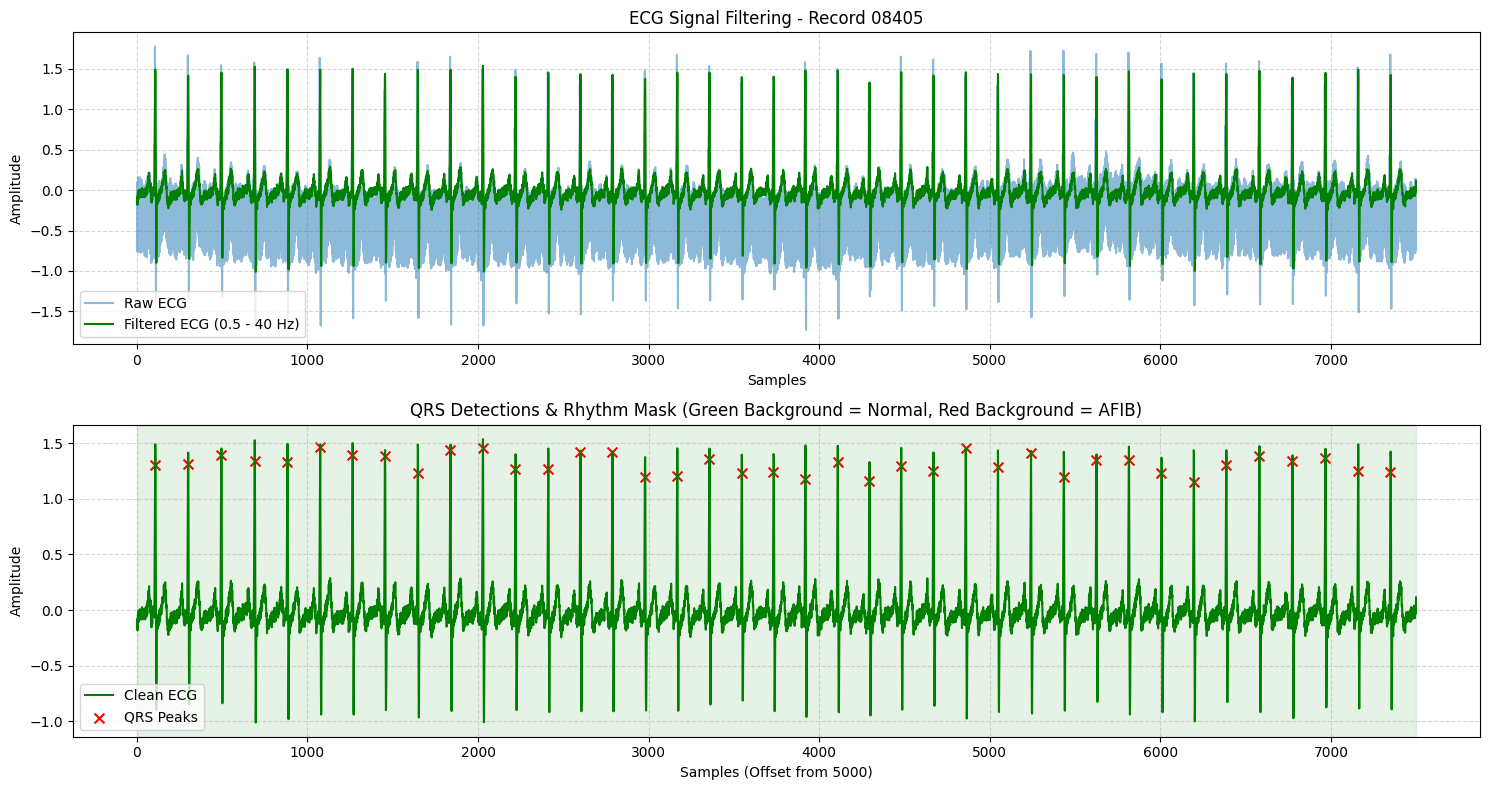

In [8]:
# Chạy thử nghiệm trên bản ghi đầu tiên trong tập Train
rec_name = "08405"
X_rec, y_rec, clean_sig, raw_sig, mask, qrs_all = process_single_record(rec_name)

# Trực quan hóa một đoạn tín hiệu 30 giây để kiểm tra bộ lọc, nhãn và đỉnh QRS
start_sample = 5000
end_sample = 12500  # 30 giây ở tần số 250Hz

plt.figure(figsize=(15, 8))

# Subplot 1: Tín hiệu thô vs Tín hiệu sau lọc
plt.subplot(2, 1, 1)
plt.plot(raw_sig[start_sample:end_sample], label="Raw ECG", alpha=0.5)
plt.plot(clean_sig[start_sample:end_sample], label="Filtered ECG (0.5 - 40 Hz)", color="green")
plt.title(f"ECG Signal Filtering - Record {rec_name}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Subplot 2: Tín hiệu sau lọc, đỉnh QRS và phân vùng nhãn
plt.subplot(2, 1, 2)
subset_clean = clean_sig[start_sample:end_sample]
subset_mask = mask[start_sample:end_sample]
subset_qrs = qrs_all[(qrs_all >= start_sample) & (qrs_all < end_sample)] - start_sample

plt.plot(subset_clean, color="green", label="Clean ECG")
plt.scatter(subset_qrs, subset_clean[subset_qrs], color="red", marker="x", s=50, label="QRS Peaks")

# Vẽ màu nền đại diện cho nhãn nhịp
start_idx = 0
for i in range(len(subset_mask)):
    if i == 0 or subset_mask[i] != subset_mask[i-1]:
        start_idx = i
    if i == len(subset_mask) - 1 or subset_mask[i] != subset_mask[i+1]:
        end_idx = i
        label_val = subset_mask[start_idx]
        if label_val == LABEL_NORMAL:
            plt.axvspan(start_idx, end_idx, color="green", alpha=0.1)
        elif label_val == LABEL_AFIB:
            plt.axvspan(start_idx, end_idx, color="red", alpha=0.1)
        else:
            plt.axvspan(start_idx, end_idx, color="grey", alpha=0.1)

plt.title("QRS Detections & Rhythm Mask (Green Background = Normal, Red Background = AFIB)")
plt.xlabel(f"Samples (Offset from {start_sample})")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("verification_plot.png", dpi=150)
plt.show()

### 7. Tiến hành tiền xử lý toàn bộ tập dữ liệu (Batch Processing) & Lưu file

In [ ]:
def process_records_list(records_list):
    """
    Gộp các dữ liệu sau tiền xử lý của danh sách records
    """
    X_all, y_all = [], []
    for rec in records_list:
        X_rec, y_rec, _, _, _, _ = process_single_record(rec)
        if len(X_rec) > 0:
            X_all.append(X_rec)
            y_all.append(y_rec)
    if X_all:
        return np.concatenate(X_all, axis=0), np.concatenate(y_all, axis=0)
    else:
        return np.array([]), np.array([])

# Đảm bảo thư mục lưu dữ liệu tồn tại
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("==============================================")
print("BẮT ĐẦU XỬ LÝ TẬP TRAIN SPLIT...")
print("==============================================")
X_train, y_train = process_records_list(TRAIN_RECORDS)
np.save(DATA_DIR / "X_train.npy", X_train)
np.save(DATA_DIR / "y_train.npy", y_train)
print(f"-> Đã lưu Train Split: X_train = {X_train.shape}, y_train = {y_train.shape}\n")

print("==============================================")
print("BẮT ĐẦU XỬ LÝ TẬP VAL SPLIT...")
print("==============================================")
X_val, y_val = process_records_list(VAL_RECORDS)
np.save(DATA_DIR / "X_val.npy", X_val)
np.save(DATA_DIR / "y_val.npy", y_val)
print(f"-> Đã lưu Val Split: X_val = {X_val.shape}, y_val = {y_val.shape}\n")

print("==============================================")
print("BẮT ĐẦU XỬ LÝ TẬP TEST SPLIT...")
print("==============================================")
# Tự động tìm tập Test các record chưa sử dụng
all_hea_files = sorted(RAW_AFDB_DIR.glob("*.hea"))
all_records = [f.stem for f in all_hea_files]
used_records = set(TRAIN_RECORDS + VAL_RECORDS) | EXCLUDED_RECORDS
TEST_RECORDS = [r for r in all_records if r not in used_records]
print(f"Các records tập Test tìm thấy: {TEST_RECORDS}")

X_test, y_test = process_records_list(TEST_RECORDS)
np.save(DATA_DIR / "X_test.npy", X_test)
np.save(DATA_DIR / "y_test.npy", y_test)
print(f"-> Đã lưu Test Split: X_test = {X_test.shape}, y_test = {y_test.shape}\n")

print("==============================================")
print("PHÂN PHỐI NHÃN TRONG CÁC TẬP DỮ LIỆU ĐẦU RA")
print("==============================================")
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    vals, counts = np.unique(y, return_counts=True)
    dist_dict = dict(zip(vals, counts))
    print(f"{name} Distribution: Normal (0) = {dist_dict.get(0, 0)}, AFIB (1) = {dist_dict.get(1, 0)}")